## E5

In [32]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


### Encuentre el par de estaciones de metro contiguas que tengan mayor diferencia en el costo de con struccion de su estructura sobre tierra.


In [33]:
estaciones = gpd.read_file("datos_geoespaciales/Metro 2020/Estaciones_2020/Estaciones_2020.shp")
lineas = gpd.read_file("datos_geoespaciales/Metro 2020/Lineas_2020/Lineas_2020.shp")
distritos = gpd.read_file("datos_geoespaciales/Distritos Censales/Distritos Censales RM.shp")
centroides_distritos = gpd.read_file("datos_geoespaciales/Distritos Censales/centroides Distritos Censales RM.shp")
comunas = gpd.read_file("datos_geoespaciales/Comunas/comunas.shp")

In [34]:
estaciones = estaciones.to_crs(epsg=32719)
distritos = distritos.to_crs(epsg=32719)
lineas = lineas.to_crs(epsg=32719)
centroides_distritos = centroides_distritos.to_crs(epsg=32719)
comunas = comunas.to_crs(epsg=32719)

1. asignar costo a cada estación

In [35]:
join = gpd.sjoin(estaciones, distritos, predicate="within")

# nos quedamos con el costo, que es el valor de 1 m2 en UF del distrito donde se encuentra cada estación
estaciones_costo = join[["LINEA", "NOMBRE", "1_UF_M2", "geometry", "POINT_X", "POINT_Y"]].copy()

In [36]:
estaciones_costo

,LINEA,NOMBRE,1_UF_M2,geometry,POINT_X,POINT_Y
0,L2,El Parrón,4.97,POINT (345717.366 6289105.444),345717.3664,6.289105e+06
1,L5,Cumming,10.25,POINT (344899.12 6298781.571),344899.1198,6.298782e+06
2,L5,Quinta Normal,5.61,POINT (343808.803 6298622.125),343809.1081,6.298628e+06
3,L4A,San Ramón,5.09,POINT (347436.975 6287501.27),346685.4133,6.287624e+06
4,L4A,Santa Rosa,4.42,POINT (348282.582 6287378.409),348282.5816,6.287378e+06
...,...,...,...,...,...,...
122,L2,Lo Espejo,4.12,POINT (345264.86 6286901.58),0.0000,0.000000e+00
123,L2,Observatorio,4.70,POINT (344934.152 6285352.774),0.0000,0.000000e+00
124,L2,Lo Martínez,3.83,POINT (344670.554 6284110.212),0.0000,0.000000e+00
125,L2,Hospital El Pino,3.71,POINT (344396.214 6282872.929),0.0000,0.000000e+00


In [37]:
lineas.head()

,OBJECTID,ID_LINEA,LINEA,LENGTH,Shape_Leng,Shape_Le_1,geometry
0,3,2,L2,18315.942,20087.016072,1301.975352,"LINESTRING (345717.366 6289105.444, 345558.641..."
1,4,2,L2,18315.942,20087.016072,1057.384032,"LINESTRING (345942.814 6290138.514, 345720.163..."
2,5,2,L2,18315.942,20087.016072,802.130950,"LINESTRING (346115.548 6290921.826, 345957.012..."
3,6,2,L2,18315.942,20087.016072,599.761286,"LINESTRING (346433.545 6292352.859, 346407.024..."
4,7,2,L2,18315.942,20087.016072,866.182956,"LINESTRING (346302.962 6291767.49, 346118.286 ..."


In [38]:
lineas_disueltas = lineas.dissolve(by="LINEA").reset_index()
lineas_geom = lineas_disueltas[["LINEA", "geometry"]].rename(columns={"geometry": "geometry_linea"})

In [39]:
lineas_geom.head()

,LINEA,geometry_linea
0,L1,"MULTILINESTRING ((340570.879 6296683.041, 3407..."
1,L2,"MULTILINESTRING ((345717.366 6289105.444, 3455..."
2,L3,"MULTILINESTRING ((354013.447 6297330.697, 3540..."
3,L4,"MULTILINESTRING ((353644.115 6280922.484, 3536..."
4,L4A,"MULTILINESTRING ((348282.582 6287378.409, 3482..."


In [40]:
estaciones_linea = estaciones_costo.merge(lineas_geom, on="LINEA", how="left")

In [41]:
estaciones_linea.head()

,LINEA,NOMBRE,1_UF_M2,geometry,POINT_X,POINT_Y,geometry_linea
0,L2,El Parrón,4.97,POINT (345717.366 6289105.444),345717.3664,6.289105e+06,"MULTILINESTRING ((345717.366 6289105.444, 3455..."
1,L5,Cumming,10.25,POINT (344899.12 6298781.571),344899.1198,6.298782e+06,"MULTILINESTRING ((351409.624 6289970.456, 3514..."
2,L5,Quinta Normal,5.61,POINT (343808.803 6298622.125),343809.1081,6.298628e+06,"MULTILINESTRING ((351409.624 6289970.456, 3514..."
3,L4A,San Ramón,5.09,POINT (347436.975 6287501.27),346685.4133,6.287624e+06,"MULTILINESTRING ((348282.582 6287378.409, 3482..."
4,L4A,Santa Rosa,4.42,POINT (348282.582 6287378.409),348282.5816,6.287378e+06,"MULTILINESTRING ((348282.582 6287378.409, 3482..."


In [42]:
estaciones_linea['LINEA'].value_counts()

LINEA
L5      23
L2      21
L1      21
L4      19
COMB    17
L3      15
L6       7
L4A      4
Name: count, dtype: int64

In [43]:
estaciones.columns.tolist()

['OBJECTID',
 'ID_LINEA',
 'LINEA',
 'ESTACION',
 'NOMBRE',
 'POINT_X',
 'POINT_Y',
 'geometry']

In [44]:
# líneas válidas (sin COMB) y orden para desempatar
lineas_validas = lineas_geom[lineas_geom["LINEA"] != "COMB"].copy()
orden_lineas = {"L1": 1, "L2": 2, "L3": 3, "L4": 4, "L4A": 5, "L5": 6, "L6": 7}
lineas_validas["orden"] = lineas_validas["LINEA"].map(orden_lineas)

# separar estaciones normales y combinaciones
est_normales = estaciones_costo[estaciones_costo["LINEA"] != "COMB"].copy()
est_comb = estaciones_costo[estaciones_costo["LINEA"] == "COMB"].copy()

# reasignar cada COMB a la línea más cercana; si empata, a la de menor orden
nuevas_lineas = []
for _, est in est_comb.iterrows():
    candidatos = lineas_validas.copy()
    candidatos["dist"] = candidatos["geometry_linea"].distance(est["geometry"])
    candidatos = candidatos.sort_values(["dist", "orden"])
    nuevas_lineas.append(candidatos.iloc[0]["LINEA"])

est_comb["LINEA"] = nuevas_lineas

# reconstruir estaciones_costo con COMB ya reasignadas
estaciones_costo = pd.concat([est_normales, est_comb], ignore_index=True)

In [45]:
estaciones_linea = estaciones_costo.merge(lineas_geom, on="LINEA", how="left")

In [46]:
estaciones_linea["geometry_linea"].isna().sum()

0

In [47]:
estaciones_linea["dist_sobre_linea"] = estaciones_linea.apply(
    lambda row: row["geometry_linea"].project(row["geometry"]),
    axis=1
)

2. ordenar las estaciones dentro de cada línea y crear la estación siguiente:

In [48]:
estaciones_linea = estaciones_linea.sort_values(["LINEA", "dist_sobre_linea"]).copy()

estaciones_linea["NOMBRE_sig"] = estaciones_linea.groupby("LINEA")["NOMBRE"].shift(-1)
estaciones_linea["COSTO_sig"] = estaciones_linea.groupby("LINEA")["1_UF_M2"].shift(-1)

3. calcular la diferencia y quedarnos con el mayor:

In [49]:
estaciones_linea["dif_costo"] = abs(estaciones_linea["1_UF_M2"] - estaciones_linea["COSTO_sig"])

pares = estaciones_linea.dropna(subset=["NOMBRE_sig"]).copy()
max_row = pares.loc[pares["dif_costo"].idxmax()]

max_row[["LINEA", "NOMBRE", "NOMBRE_sig", "1_UF_M2", "COSTO_sig", "dif_costo"]]

LINEA                       L4
NOMBRE        Francisco Bilbao
NOMBRE_sig            Tobalaba
1_UF_M2                   8.24
COSTO_sig                40.83
dif_costo                32.59
Name: 21, dtype: object

#### Bonus (fuera del ejercicio): Top 5 estaciones con mayor diferencia de costo con su siguiente estación.

In [50]:
top5 = pares[["LINEA", "NOMBRE", "NOMBRE_sig", "1_UF_M2", "COSTO_sig", "dif_costo"]] \
    .sort_values("dif_costo", ascending=False) \
    .head(5)

top5

,LINEA,NOMBRE,NOMBRE_sig,1_UF_M2,COSTO_sig,dif_costo
21,L4,Francisco Bilbao,Tobalaba,8.24,40.83,32.59
56,L1,El Salvador,Manuel Montt,16.77,41.13,24.36
1,L5,Cumming,Bellas Artes,10.25,31.09,20.84
58,L1,Manuel Montt,Pedro de Valdivia,41.13,21.62,19.51
70,L1,Hernando de Magallanes,Los Dominicos,22.90,7.13,15.77


### Grafique los distritos censales de Santiago para los cuales los habitantes que viven en su centro estan a no mas de 15 minutos caminando de una estacion de metro.

Vamos a asumir que se pueden caminar 5 km en una hora, entonces 15 minutos es 1.25 km. Por lo tanto, vamos a quedarnos con los distritos censales cuyo centroide esté a menos de 1.25 km de una estación de metro.

Como supuesto adicional, nos centraremos en la Santiago Urbano.

In [51]:
centroides_distritos["dist_metro"] = centroides_distritos.geometry.apply(
    lambda p: estaciones.distance(p).min()
)

centroides_15min = centroides_distritos[centroides_distritos["dist_metro"] <= 1250].copy()

In [52]:
chile_urbano = gpd.read_file('datos_geoespaciales/Areas Urbanas/areas_urbanas.shp')
santiago_urbano = chile_urbano[chile_urbano['NOMBRE'] == 'Santiago']
santiago_urbano = santiago_urbano.to_crs(epsg=32719)
santiago_urbano.head()

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,geometry
385,Santiago,Ciudad,427491.444262,5.821041e+08,"MULTIPOLYGON (((338445.291 6306151.222, 338289..."


In [53]:
# distritos que caen dentro de santiago urbano
distritos_santiago_urb = gpd.sjoin(
    distritos,
    santiago_urbano[["geometry"]],
    how="inner",
    predicate="intersects"
).drop(columns=["index_right"])

# centroides accesibles que caen dentro de Santiago urbano, aquí basta within
centroides_15min_santiago_urb = gpd.sjoin(
    centroides_15min,
    santiago_urbano[["geometry"]],
    how="inner",
    predicate="within"
).drop(columns=["index_right"])

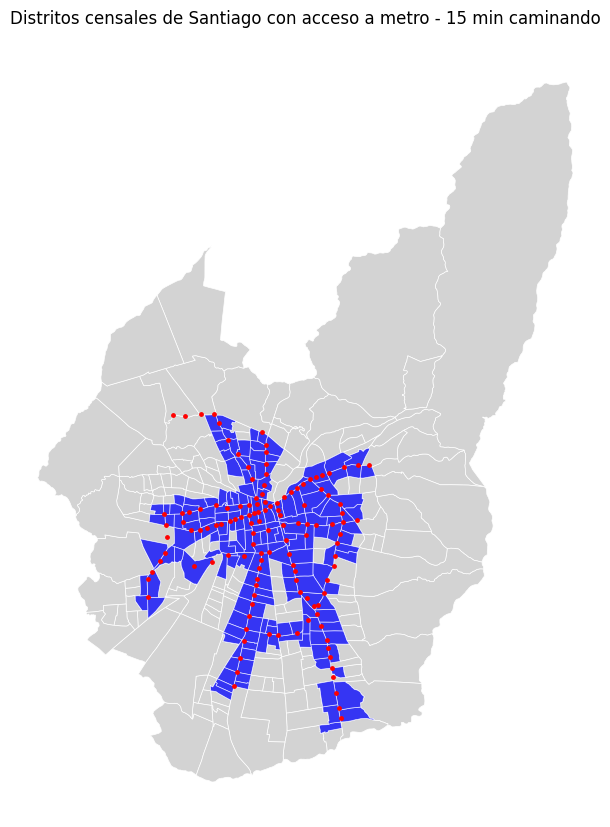

In [54]:
fig, ax = plt.subplots(figsize=(10, 10))

# fondo: todos los distritos de Santiago
distritos_santiago_urb.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.5)

# encima: distritos accesibles a <= 15 min
distritos_santiago_urb[distritos_santiago_urb["CODIGO"].isin(centroides_15min_santiago_urb["CODIGO"])].plot(
    ax=ax, color="blue", alpha=0.75, edgecolor="white", linewidth=0.5
)

# estaciones de metro
estaciones.plot(ax=ax, color="red", markersize=6)

ax.set_title("Distritos censales de Santiago con acceso a metro - 15 min caminando")
ax.axis("off")

plt.show()

### Estime, para cada linea de metro, el costo de expropiacion de una ciclovia que tenga el mismo trazado, incorporando tambien en el analisis el costo del espacio que utilizaria un estacionamiento de bicicletas por cada estacion de metro.

In [55]:
ancho_ciclovia = 3.0      # metros, por ejemplo ciclovía bidireccional
area_bicicletero = 25.0   # m2 por estación, supuesto editable

Geometría de cada línea

In [56]:
lineas_disueltas = lineas.dissolve(by="LINEA").reset_index()

# buffer de la ciclovía
lineas_buffer = lineas_disueltas.copy()
lineas_buffer["geometry"] = lineas_buffer.geometry.buffer(ancho_ciclovia / 2)

Costo de expropiación de la ciclovía: área * costo por m2

In [57]:
# intersectar buffer de línea con distritos
inter = gpd.overlay(
    lineas_buffer[["LINEA", "geometry"]],
    distritos[["CODIGO", "1_UF_M2", "geometry"]],
    how="intersection"
)

# área ocupada dentro de cada distrito
inter["area_m2"] = inter.geometry.area

# costo en UF
inter["costo_ciclovia_UF"] = inter["area_m2"] * inter["1_UF_M2"]

# costo total de ciclovía por línea
costo_ciclovia = (
    inter.groupby("LINEA", as_index=False)["costo_ciclovia_UF"]
    .sum()
)

Costo de bicicletero por estación

In [58]:
costo_estaciones = estaciones_costo.copy()
costo_estaciones["costo_bicicletero_UF"] = costo_estaciones["1_UF_M2"] * area_bicicletero

costo_bicicleteros = (
    costo_estaciones.groupby("LINEA", as_index=False)["costo_bicicletero_UF"]
    .sum()
)

# opcional: contar estaciones por línea
n_estaciones = (
    costo_estaciones.groupby("LINEA", as_index=False)["NOMBRE"]
    .count()
    .rename(columns={"NOMBRE": "n_estaciones"})
)

Costo por línea

In [59]:
resultado = (
    costo_ciclovia
    .merge(costo_bicicleteros, on="LINEA", how="outer")
    .merge(n_estaciones, on="LINEA", how="outer")
    .fillna(0)
)

resultado["costo_total_UF"] = (
    resultado["costo_ciclovia_UF"] + resultado["costo_bicicletero_UF"]
)

resultado = resultado.sort_values("costo_total_UF", ascending=False)

resultado

,LINEA,costo_ciclovia_UF,costo_bicicletero_UF,n_estaciones,costo_total_UF
0,L1,1.167263e+06,11660.00,24,1.178923e+06
5,L5,8.039159e+05,5866.25,26,8.097822e+05
2,L3,6.979186e+05,4652.00,18,7.025706e+05
6,L6,5.473428e+05,2016.75,9,5.493595e+05
1,L2,5.166171e+05,4120.50,24,5.207376e+05
3,L4,5.134432e+05,4253.25,22,5.176964e+05
4,L4A,1.208564e+05,436.25,4,1.212927e+05


### Grafique las comunas urbanas de Santiago, donde cada una esta coloreada con el color de la linea de metro mas cercana. Defina los colores de acuerdo a los oficiales del Metro de Santiago.

In [60]:
# comunas urbanas de Santiago
comunas_urbanas = gpd.sjoin(
    comunas.to_crs(epsg=32719),
    santiago_urbano[["geometry"]],
    how="inner",
    predicate="intersects"
).drop(columns="index_right")

# una geometría por línea
lineas_disueltas = lineas.to_crs(epsg=32719).dissolve(by="LINEA").reset_index()

# comuna -> línea más cercana
comunas_linea = gpd.sjoin_nearest(
    comunas_urbanas,
    lineas_disueltas[["LINEA", "geometry"]],
    how="left",
    distance_col="dist_linea"
)

colores_metro = {
    "L1": "#E51C23", 
    "L2": "#F7D117",  
    "L3": "#8C6239",   
    "L4": "#1E88E5",  
    "L4A": "#4FC3F7",  
    "L5": "#2E7D32",  
    "L6": "#8E24AA"   
}

comunas_linea["color_linea"] = comunas_linea["LINEA"].map(colores_metro)

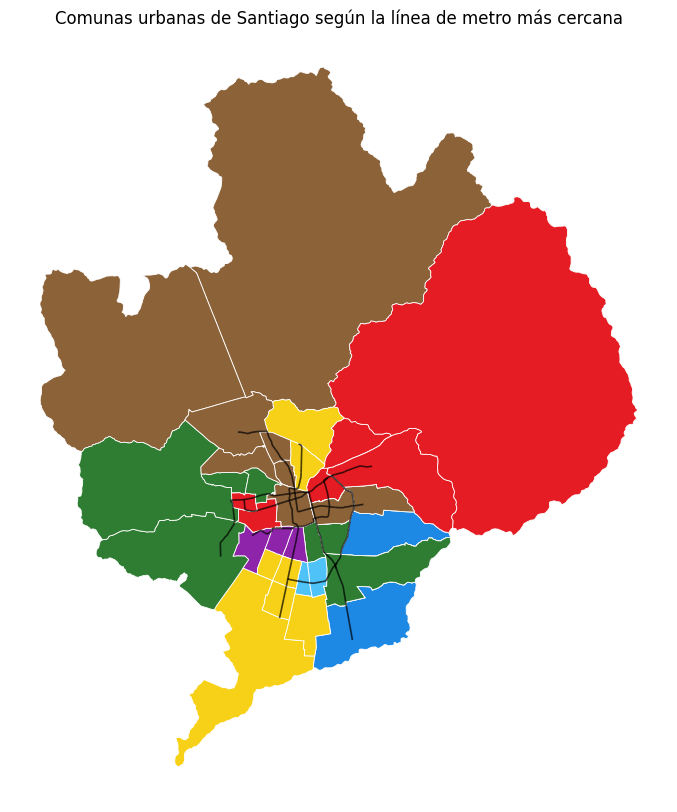

In [61]:
fig, ax = plt.subplots(figsize=(10, 10))

comunas_linea.plot(
    ax=ax,
    color=comunas_linea["color_linea"],
    edgecolor="white",
    linewidth=0.6
)

lineas_disueltas.plot(ax=ax, color="black", linewidth=1.2, alpha=0.7)

ax.set_title("Comunas urbanas de Santiago según la línea de metro más cercana")
ax.axis("off")
plt.show()

### PROPUESTO

### Diseñe una nueva linea de metro (trazado y estaciones) que cumpla con las siguientes exigencias:

• Una extension aproximadamente igual al promedio de las lineas ya existentes.

• Distancia entre estaciones aproximadamente igual al promedio de las ya existentes.

• La proporcion de cada grupo socioeconomico en los distritos cruzados debe ser similar al promedio del resto de las lineas existentes.

• 75% de las estaciones ubicadas en distritos que actualmente no tienen estaciones.

• El cruce con otra linea debe ser en una estacion que pase por ambas

In [ ]:
# asegurar mismo crs proyectado
estaciones = estaciones.to_crs(epsg=32719)
lineas = lineas.to_crs(epsg=32719)
distritos = distritos.to_crs(epsg=32719)

# 1) longitud promedio de las líneas existentes
lineas_disueltas = lineas.dissolve(by="LINEA").reset_index()
longitud_promedio = lineas_disueltas.geometry.length.mean()

# 2) distritos que actualmente tienen estación
distritos_con_estacion = gpd.sjoin(
    distritos[["CODIGO", "geometry"]],
    estaciones[["geometry"]],
    how="inner",
    predicate="intersects"
)["CODIGO"].unique()

# 3) estaciones con línea única y costo/distrito asociado
join_est = gpd.sjoin(
    estaciones,
    distritos[["CODIGO", "E", "D", "C3", "C2", "ABC1", "1_UF_M2", "geometry"]],
    how="left",
    predicate="within"
).drop(columns="index_right")

estaciones_costo = join_est[["LINEA", "NOMBRE", "CODIGO", "E", "D", "C3", "C2", "ABC1", "1_UF_M2", "geometry"]].copy()

# 4) reasignar COMB a la línea real más cercana, desempate por orden
lineas_geom = lineas_disueltas[["LINEA", "geometry"]].rename(columns={"geometry": "geometry_linea"}).copy()
lineas_validas = lineas_geom[lineas_geom["LINEA"] != "COMB"].copy()

orden_lineas = {"L1": 1, "L2": 2, "L3": 3, "L4": 4, "L4A": 5, "L5": 6, "L6": 7}
lineas_validas["orden"] = lineas_validas["LINEA"].map(orden_lineas)

est_normales = estaciones_costo[estaciones_costo["LINEA"] != "COMB"].copy()
est_comb = estaciones_costo[estaciones_costo["LINEA"] == "COMB"].copy()

nuevas_lineas = []
for _, est in est_comb.iterrows():
    candidatos = lineas_validas.copy()
    candidatos["dist"] = candidatos["geometry_linea"].distance(est["geometry"])
    candidatos = candidatos.sort_values(["dist", "orden"])
    nuevas_lineas.append(candidatos.iloc[0]["LINEA"])

if len(est_comb) > 0:
    est_comb["LINEA"] = nuevas_lineas

estaciones_costo = pd.concat([est_normales, est_comb], ignore_index=True)

# 5) distancia promedio entre estaciones consecutivas
est_tmp = estaciones_costo.merge(
    lineas_geom,
    on="LINEA",
    how="left"
).copy()

est_tmp["dist_sobre_linea"] = est_tmp.apply(
    lambda row: row["geometry_linea"].project(row["geometry"]),
    axis=1
)

est_tmp = est_tmp.sort_values(["LINEA", "dist_sobre_linea"]).copy()
est_tmp["dist_sig"] = (
    est_tmp.groupby("LINEA")["dist_sobre_linea"].shift(-1) - est_tmp["dist_sobre_linea"]
)

dist_promedio_estaciones = est_tmp["dist_sig"].dropna().mean()

# 6) composición socioeconómica objetivo
estaciones_distrito = gpd.sjoin(
    estaciones_costo[["LINEA", "NOMBRE", "geometry"]],
    distritos[["CODIGO", "E", "D", "C3", "C2", "ABC1", "geometry"]],
    how="left",
    predicate="within"
).drop(columns="index_right")

comp_linea = estaciones_distrito.groupby("LINEA")[["E", "D", "C3", "C2", "ABC1"]].mean()
comp_objetivo = comp_linea.mean()

print("longitud_promedio =", round(longitud_promedio, 2))
print("dist_promedio_estaciones =", round(dist_promedio_estaciones, 2))
print("comp_objetivo:")
print(comp_objetivo.round(2))

longitud_promedio = 20591.15
dist_promedio_estaciones = 1146.18
comp_objetivo:
E        179.47
D       1214.88
C3      1472.49
C2      1289.22
ABC1     462.36
dtype: float64


In [ ]:
from shapely.geometry import LineString
import numpy as np

def construir_linea_desde_cruce(punto, theta, largo):
    dx = np.cos(theta) * largo / 2
    dy = np.sin(theta) * largo / 2
    return LineString([
        (punto.x - dx, punto.y - dy),
        (punto.x + dx, punto.y + dy)
    ])

def generar_estaciones(linea, punto_cruce, dist_prom):
    dist_cruce = linea.project(punto_cruce)
    dist_izq = np.arange(dist_cruce, -1, -dist_prom)[::-1]
    dist_der = np.arange(dist_cruce + dist_prom, linea.length + 1e-9, dist_prom)
    distancias = np.concatenate([dist_izq, dist_der])
    puntos = [linea.interpolate(d) for d in distancias]
    return gpd.GeoDataFrame(
        {"dist_sobre_linea": distancias},
        geometry=puntos,
        crs=distritos.crs
    )

def evaluar_candidata(linea, estaciones_nuevas):
    # 1) proporción en distritos sin estación
    est_dist = gpd.sjoin(
        estaciones_nuevas,
        distritos[["CODIGO", "geometry"]],
        how="left",
        predicate="within"
    ).drop(columns="index_right")

    prop_sin = (~est_dist["CODIGO"].isin(distritos_con_estacion)).mean()

    # 2) composición socioeconómica de distritos cruzados
    linea_gdf = gpd.GeoDataFrame({"id":[1]}, geometry=[linea], crs=distritos.crs)
    distr_cruz = gpd.sjoin(
        distritos[["E","D","C3","C2","ABC1","geometry"]],
        linea_gdf,
        how="inner",
        predicate="intersects"
    ).drop(columns="index_right")

    comp_nueva = distr_cruz[["E","D","C3","C2","ABC1"]].mean()
    dist_soc = np.linalg.norm(comp_nueva.values - comp_objetivo.values)

    # 3) score
    penal_75 = max(0, 0.75 - prop_sin)
    score = 1000 * penal_75 + dist_soc

    return {
        "prop_sin": prop_sin,
        "dist_soc": dist_soc,
        "score": score,
        "n_estaciones": len(estaciones_nuevas)
    }

resultados = []

angulos = np.deg2rad(np.arange(0, 180, 5))

for _, est in estaciones.iterrows():
    for theta in angulos:
        linea = construir_linea_desde_cruce(est.geometry, theta, longitud_promedio)
        estaciones_cand = generar_estaciones(linea, est.geometry, dist_promedio_estaciones)
        met = evaluar_candidata(linea, estaciones_cand)

        resultados.append({
            "cruce": est["NOMBRE"],
            "linea_cruce": est["LINEA"],
            "theta_deg": np.rad2deg(theta),
            **met
        })

resultados = pd.DataFrame(resultados).sort_values("score")
resultados.head(10)

,cruce,linea_cruce,theta_deg,prop_sin,dist_soc,score,n_estaciones
1521,Lo Vial,L2,45.0,0.764706,108.767897,108.767897,17
1634,Pedrero,L5,70.0,0.647059,35.411138,138.352314,17
2657,Los Leones,COMB,145.0,0.705882,110.291042,154.408689,17
1591,Camino Agrícola,L5,35.0,0.764706,167.307813,167.307813,17
1110,Patronato,L2,150.0,0.705882,124.327970,168.445617,17
1485,Departamental,L2,45.0,0.764706,172.383103,172.383103,17
1633,Pedrero,L5,65.0,0.647059,73.619454,176.560631,17
2656,Los Leones,COMB,140.0,0.705882,136.090915,180.208562,17
657,Grecia,L4,45.0,0.764706,181.203276,181.203276,17
3884,Plaza Chacabuco,L3,160.0,0.647059,90.797685,193.738861,17


In [64]:
# fijar mejor solución encontrada
cruce_nombre = "Lo Vial"
theta_deg = 45.0
theta = np.deg2rad(theta_deg)

# estación de cruce
estacion_obj = estaciones[estaciones["NOMBRE"] == cruce_nombre].iloc[0]
p = estacion_obj.geometry

# construir línea final
dx = np.cos(theta) * longitud_promedio / 2
dy = np.sin(theta) * longitud_promedio / 2

linea_nueva = LineString([
    (p.x - dx, p.y - dy),
    (p.x + dx, p.y + dy)
])

# generar estaciones sobre la línea, forzando una en el cruce
dist_cruce = linea_nueva.project(p)
d = dist_promedio_estaciones

dist_izq = np.arange(dist_cruce, -1, -d)[::-1]
dist_der = np.arange(dist_cruce + d, linea_nueva.length + 1e-9, d)
distancias = np.concatenate([dist_izq, dist_der])

puntos_estaciones = [linea_nueva.interpolate(x) for x in distancias]

estaciones_nuevas = gpd.GeoDataFrame(
    {
        "id_est": range(1, len(distancias) + 1),
        "dist_sobre_linea": distancias
    },
    geometry=puntos_estaciones,
    crs=distritos.crs
)

print("Largo línea nueva:", round(linea_nueva.length, 2))
print("Número de estaciones:", len(estaciones_nuevas))
print("Cruce en:", cruce_nombre, "-", estacion_obj["LINEA"])

Largo línea nueva: 20591.15
Número de estaciones: 17
Cruce en: Lo Vial - L2


In [66]:
# 1) tomar la mejor solución
mejor = resultados.iloc[0]

cruce_nombre = mejor["cruce"]
theta_deg = mejor["theta_deg"]
theta = np.deg2rad(theta_deg)

print("Mejor solución:")
print(mejor)

# 2) obtener la estación de cruce
estacion_obj = estaciones[estaciones["NOMBRE"] == cruce_nombre].iloc[0]
punto_cruce = estacion_obj.geometry

# 3) reconstruir la línea
linea_nueva = construir_linea_desde_cruce(
    punto=punto_cruce,
    theta=theta,
    largo=longitud_promedio
)

# 4) reconstruir las estaciones
estaciones_nuevas = generar_estaciones(
    linea=linea_nueva,
    punto_cruce=punto_cruce,
    dist_prom=dist_promedio_estaciones
)

# 5) guardar la línea como GeoDataFrame
linea_nueva_gdf = gpd.GeoDataFrame(
    {
        "cruce": [cruce_nombre],
        "linea_cruce": [mejor["linea_cruce"]],
        "theta_deg": [theta_deg]
    },
    geometry=[linea_nueva],
    crs=distritos.crs
)

print("Largo reconstruido:", round(linea_nueva.length, 2))
print("Número de estaciones reconstruidas:", len(estaciones_nuevas))

Mejor solución:
cruce              Lo Vial
linea_cruce             L2
theta_deg             45.0
prop_sin          0.764706
dist_soc        108.767897
score           108.767897
n_estaciones            17
Name: 1521, dtype: object
Largo reconstruido: 20591.15
Número de estaciones reconstruidas: 17


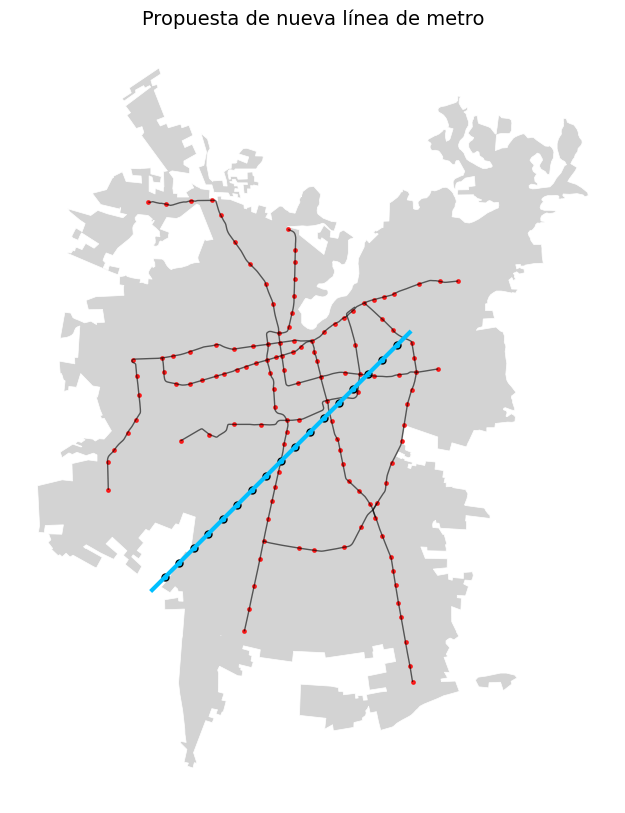

In [70]:
fig, ax = plt.subplots(figsize=(10, 10))

# santiago urbano de fondo
santiago_urbano.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.5)

# líneas existentes
lineas_disueltas.plot(ax=ax, color="black", linewidth=1, alpha=0.6)

# estaciones existentes
estaciones.plot(ax=ax, color="red", markersize=6, alpha=0.8)

# nueva línea
linea_nueva_gdf.plot(ax=ax, color="deepskyblue", linewidth=3)

# nuevas estaciones
estaciones_nuevas.plot(ax=ax, color="deepskyblue", markersize=25, edgecolor="black")

ax.set_title("Propuesta de nueva línea de metro", fontsize=14)
ax.axis("off")

plt.show()